# Indice Synthétique de Convergence Technologique — v4

## Journal des versions

### v1 → C2 domine la PCA (loading=1.000), composantes orthogonales, indice plat à 0.5
### v2 → log-transform insuffisant, filtre binaire C2, std déséquilibrées, paires taxonomiques
### v3 → rank transform PAR ANNÉE : équilibre les variances mais détruit l'information temporelle
         → série agrégée plate à 0.42 par construction mécanique
         → C1×C3 = -0.41 : anti-corrélation structurelle (spécialistes vs généralistes)
         → Top 10 dominé par paires stables de longue date, pas par émergences
         → C4 std=0.176 au lieu de 0.289 : trop de zéros pour la rank transform

### v4 → quatre corrections
# 1. RANK TRANSFORM GLOBALE (sur tout le panel, pas par année)
#    → préserve l'information temporelle tout en équilibrant les variances
#    → une paire qui monte dans le temps recevra des rangs croissants
#
# 2. REMPLACEMENT DE C3 par ΔJaccard (variation temporelle du Jaccard)
#    → C3 (centralité croisée) était anti-corrélée à C1 (-0.41) et ne capturait
#      pas la dynamique : elle mesurait le niveau de centralité, pas son évolution
#    → ΔJaccard(i,j,t) = Jaccard(t) - Jaccard(t-5) mesure l'accélération
#      de la convergence, ce qu'on veut vraiment détecter
#    → cela distingue une paire stable (ΔJaccard≈0) d'une paire en convergence active
#
# 3. C4 TRAITÉE SÉPARÉMENT (rank transform uniquement sur valeurs non nulles)
#    → 85% de zéros exacts rendaient la rank transform de C4 non informative
#    → nouvelle approche : indicateur binaire (dans cluster absorbant ou non)
#      multiplié par le score d'absorption normalisé
#
# 4. POIDS RÉVISÉS : C1=0.40, C2=0.15, C3_new=0.30, C4=0.15
#    → C3_new (ΔJaccard) reçoit un poids élevé car c'est la dimension dynamique
#      qui manquait aux versions précédentes
#    → C2 réduit à 0.15 car toujours volatile malgré les corrections

## 0. Imports et paramètres

In [1]:
import pandas as pd
import numpy as np
import itertools
from collections import Counter, defaultdict
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# PARAMÈTRES
# ════════════════════════════════════════════════════════════════
WINDOW         = 5      # fenêtre glissante (années)
K_CLUSTERS     = 10
N_PCA_CLUST    = 20
CORR_WINDOW    = 5
EPS            = 1e-10
YEAR_START     = 1980
YEAR_END       = 2022   # troncature : fenêtre incomplète après 2022

# Filtres
MIN_PATENTS    = 30     # nb min de brevets/an par code
MIN_COOC       = 20     # nb min de co-occurrences sur la fenêtre
C2_SCALING_REF = 200   # seuil pour pondération dynamique C2

# ── Poids v4 ─────────────────────────────────────────────────────
# C1 (Jaccard niveau)    : 0.40 — mesure directe la plus fiable
# C2 (corrélation)       : 0.15 — signal temporel mais volatile,
#                                  réduit pour limiter le bruit
# C3 (ΔJaccard)          : 0.30 — NOUVEAU : dimension dynamique,
#                                  distingue convergences actives
#                                  des relations stables de longue date
# C4 (cluster absorbant) : 0.15 — signal rare mais discriminant
W = {
    'C1_jaccard'  : 0.40,
    'C2_corr'     : 0.15,
    'C3_delta'    : 0.30,
    'C4_cluster'  : 0.15,
}

## 1. Chargement et préparation

In [2]:
df_raw = pd.read_parquet("multi_codes_brevets.parquet")
df_raw = df_raw.dropna(subset=["year", "cpc4_list"]).copy()
df_raw["year"] = df_raw["year"].astype(int)

def normalize_cpc_list(lst):
    clean = []
    for c in lst:
        if c is None: continue
        s = str(c).upper().strip()
        if len(s) >= 3:
            clean.append(s[:4])
    return sorted(set(clean))

df_raw["cpc4"] = df_raw["cpc4_list"].apply(normalize_cpc_list)
df_raw = df_raw[df_raw["cpc4"].apply(len) >= 2].copy()

brevet_count_by_year = df_raw.groupby("year").size().to_dict()
N_mean = np.mean(list(brevet_count_by_year.values()))

print(f"Brevets : {len(df_raw):,} | Période : {df_raw['year'].min()}–{df_raw['year'].max()}")

Brevets : 1,234,382 | Période : 1980–2025


---
## C1 — Jaccard (niveau absolu) + filtre taxonomique

C1 mesure la proximité directe à chaque instant.
La rank transform sera appliquée GLOBALEMENT en aval (pas par année).

Filtre taxonomique : exclusion des paires partageant les 3 premiers
caractères CPC — ces paires sont proches par construction de la
classification, pas par convergence technologique.

In [3]:
def compute_jaccard_yearly(df, window=WINDOW, min_patents=MIN_PATENTS):
    years = sorted(df["year"].unique())
    records = []
    for t_center in years:
        t_start = t_center - window // 2
        t_end   = t_center + window // 2
        df_w = df[(df["year"] >= t_start) & (df["year"] <= t_end)]
        n_i = Counter()
        n_ij = Counter()
        for _, row in df_w.iterrows():
            codes = row["cpc4"]
            for c in codes:
                n_i[c] += 1
            for ci, cj in itertools.combinations(codes, 2):
                key = (min(ci, cj), max(ci, cj))
                n_ij[key] += 1
        for (ci, cj), count_ij in n_ij.items():
            ni, nj = n_i[ci], n_i[cj]
            if ni < min_patents or nj < min_patents:
                continue
            union = ni + nj - count_ij
            records.append({
                "cpc_i": ci, "cpc_j": cj, "year": t_center,
                "jaccard"     : count_ij / union if union > 0 else 0,
                "p_j_given_i" : count_ij / ni if ni > 0 else 0,
                "p_i_given_j" : count_ij / nj if nj > 0 else 0,
                "n_cooc"      : count_ij
            })
    return pd.DataFrame(records)


print("Calcul du Jaccard...")
df_jaccard = compute_jaccard_yearly(df_raw)
print(f"  {len(df_jaccard):,} obs. avant filtres")

# filtre n_cooc
df_jaccard = df_jaccard[df_jaccard["n_cooc"] >= MIN_COOC].copy()
print(f"  {len(df_jaccard):,} obs. après filtre n_cooc >= {MIN_COOC}")

# filtre taxonomique
df_jaccard["px_i"] = df_jaccard["cpc_i"].str[:3]
df_jaccard["px_j"] = df_jaccard["cpc_j"].str[:3]
df_jaccard = df_jaccard[df_jaccard["px_i"] != df_jaccard["px_j"]].drop(columns=["px_i","px_j"]).copy()
print(f"  {len(df_jaccard):,} obs. après filtre taxonomique")
print(f"\nJaccard — mean={df_jaccard['jaccard'].mean():.4f}, std={df_jaccard['jaccard'].std():.4f}")

Calcul du Jaccard...
  1,382,733 obs. avant filtres
  183,982 obs. après filtre n_cooc >= 20
  165,484 obs. après filtre taxonomique

Jaccard — mean=0.0202, std=0.0327


---
## C3_new — ΔJaccard : variation temporelle (NOUVELLE COMPOSANTE)

### Pourquoi remplacer C3 (centralité croisée) par ΔJaccard ?

En v3, C3 (centralité croisée) était anti-corrélée à C1 (r=-0.41).
Explication structurelle : les paires très co-occurrentes (Jaccard élevé)
sont souvent des sous-domaines spécialisés et peu centraux dans le réseau
global. Les grandes paires centrales ont un Jaccard modéré car chaque code
se connecte à de nombreux partenaires. Cette anti-corrélation comprimait
l'indice vers la moyenne (std=0.17 au lieu de 0.29).

De plus, le Top 10 de la v3 était dominé par des paires stables de longue
date (A01N×C07D en chimie agricole, toujours très actives) — pas par des
convergences émergentes. C3 mesurait le niveau de centralité, pas son
évolution.

### ΔJaccard comme mesure de la dynamique de convergence

ΔJaccard(i,j,t) = Jaccard(i,j,t) - Jaccard(i,j,t-WINDOW)

Cette mesure capture l'ACCÉLÉRATION de la convergence :
- Une paire avec Jaccard=0.30 stable depuis 20 ans → ΔJaccard≈0
- Une paire dont le Jaccard passe de 0.02 à 0.08 en 5 ans → ΔJaccard=+0.06

C'est précisément ce qui distingue une relation technologique établie
d'une convergence innovante émergente — la notion centrale dans
Acemoglu et al. (2016) et Erdi et al. (2013).

Calcul de ΔJaccard (C3 v4)...
  Paires avec historique (ΔJaccard calculé) : 106,794 (64.5%)
  ΔJaccard > 0 (convergence) : 59,267
  ΔJaccard < 0 (divergence)  : 47,521
  ΔJaccard = 0 (stable/NaN)  : 58,696

ΔJaccard — mean=0.0005, std=0.0091


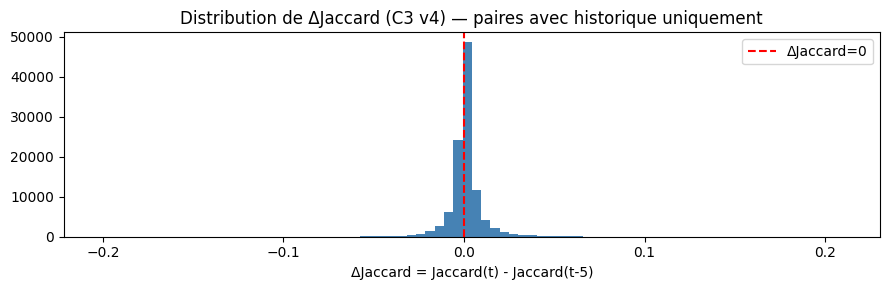

In [4]:
def compute_delta_jaccard(df_jaccard, window=WINDOW):
    """
    Calcule la variation du Jaccard entre t et t-window.
    ΔJaccard(i,j,t) = Jaccard(i,j,t) - Jaccard(i,j,t-window)

    Pour les premières années (pas d'historique suffisant),
    ΔJaccard est mis à NaN puis remplacé par 0 (pas de signal).

    Retourne le df_jaccard enrichi avec la colonne 'delta_jaccard'.
    """
    df = df_jaccard.copy().sort_values(["cpc_i", "cpc_j", "year"])

    # Jaccard décalé de WINDOW années pour chaque paire
    df_lag = df[["cpc_i", "cpc_j", "year", "jaccard"]].copy()
    df_lag["year_future"] = df_lag["year"] + window
    df_lag = df_lag.rename(columns={"jaccard": "jaccard_lag", "year": "year_lag"})

    df = df.merge(
        df_lag[["cpc_i", "cpc_j", "year_future", "jaccard_lag"]],
        left_on=["cpc_i", "cpc_j", "year"],
        right_on=["cpc_i", "cpc_j", "year_future"],
        how="left"
    ).drop(columns=["year_future"])

    df["delta_jaccard"] = df["jaccard"] - df["jaccard_lag"]
    # NaN = pas d'historique → on met 0 (neutre, ni convergence ni divergence)
    df["delta_jaccard"] = df["delta_jaccard"].fillna(0)

    return df


print("Calcul de ΔJaccard (C3 v4)...")
df_jaccard = compute_delta_jaccard(df_jaccard)

# diagnostic
has_lag = df_jaccard["jaccard_lag"].notna()
print(f"  Paires avec historique (ΔJaccard calculé) : {has_lag.sum():,} ({100*has_lag.mean():.1f}%)")
print(f"  ΔJaccard > 0 (convergence) : {(df_jaccard['delta_jaccard']>0).sum():,}")
print(f"  ΔJaccard < 0 (divergence)  : {(df_jaccard['delta_jaccard']<0).sum():,}")
print(f"  ΔJaccard = 0 (stable/NaN)  : {(df_jaccard['delta_jaccard']==0).sum():,}")
print(f"\nΔJaccard — mean={df_jaccard['delta_jaccard'].mean():.4f}, "
      f"std={df_jaccard['delta_jaccard'].std():.4f}")

# distribution
fig, ax = plt.subplots(figsize=(9, 3))
vals = df_jaccard.loc[has_lag, "delta_jaccard"]
ax.hist(vals, bins=80, color="steelblue", edgecolor="none")
ax.axvline(0, color="red", lw=1.5, ls="--", label="ΔJaccard=0")
ax.set_title("Distribution de ΔJaccard (C3 v4) — paires avec historique uniquement")
ax.set_xlabel("ΔJaccard = Jaccard(t) - Jaccard(t-5)")
ax.legend()
plt.tight_layout()
plt.show()

---
## C2 — Corrélation glissante avec pondération dynamique (inchangée)

In [5]:
def build_activity_series(df):
    records = []
    for year, grp in df.groupby("year"):
        N_year   = brevet_count_by_year[year]
        w_year   = N_mean / N_year
        activity = defaultdict(float)
        for _, row in grp.iterrows():
            codes = row["cpc4"]
            m = len(codes)
            if m < 2: continue
            w_pair = (2.0 / (m * (m - 1))) * w_year
            for c in codes:
                activity[c] += w_pair * (m - 1)
        for cpc, val in activity.items():
            records.append({"cpc4": cpc, "year": year, "activity": val})
    return pd.DataFrame(records)


def compute_rolling_corr_dynamic(df_jaccard, df_activity,
                                  window=CORR_WINDOW,
                                  scaling_ref=C2_SCALING_REF):
    """
    Corrélation glissante × min(1, n_cooc/scaling_ref).
    La pondération dynamique remplace le filtre binaire de la v2 :
    plus la paire est active, plus C2 est fiable et contribue.
    """
    pivot = df_activity.pivot(
        index="year", columns="cpc4", values="activity"
    ).fillna(0)
    cooc_lookup = df_jaccard.set_index(["cpc_i", "cpc_j", "year"])["n_cooc"].to_dict()
    pairs = df_jaccard[["cpc_i", "cpc_j"]].drop_duplicates().values.tolist()
    records = []
    for ci, cj in pairs:
        if ci not in pivot.columns or cj not in pivot.columns:
            continue
        corr = pivot[ci].rolling(window, min_periods=3).corr(pivot[cj])
        for yr, corr_raw in corr.items():
            if np.isnan(corr_raw): continue
            n = cooc_lookup.get((ci, cj, yr), 0)
            reliability = min(1.0, n / scaling_ref)
            records.append({
                "cpc_i": ci, "cpc_j": cj, "year": yr,
                "rolling_corr_raw" : corr_raw,
                "rolling_corr"     : corr_raw * reliability,
                "c2_reliability"   : reliability,
            })
    return pd.DataFrame(records)


print("Séries d'activité...")
df_activity = build_activity_series(df_raw)
print("Calcul C2...")
df_corr = compute_rolling_corr_dynamic(df_jaccard, df_activity)
print(f"  {len(df_corr):,} observations")
print(f"  reliability moyenne : {df_corr['c2_reliability'].mean():.3f}")

Séries d'activité...
Calcul C2...
  528,334 observations
  reliability moyenne : 0.108


---
## C4 — Cluster absorbant avec traitement séparé des zéros

### Problème v3 : std(C4)=0.176 au lieu de 0.289
85% de zéros exacts dans cluster_absorption rendaient la rank transform
non informative : tous les zéros recevaient des rangs groupés entre
0.235 et 0.45, comprimant la distribution.

### Solution v4 : traitement en deux étapes
1. Indicateur binaire : is_absorbing(i,j,t) ∈ {0,1}
2. Score continu uniquement sur les paires absorbantes :
   rank transform du score d'absorption PARMI les paires non nulles
3. C4_final = is_absorbing × rank_score
→ Les paires non absorbantes restent à 0 (pas de signal)
→ Les paires absorbantes ont un score gradué sur [0,1]

In [6]:
def build_cooc_matrix(df, year_start, year_end):
    df_w = df[(df["year"] >= year_start) & (df["year"] <= year_end)]
    df_w = df_w[df_w["cpc4"].apply(lambda x: len(x) >= 2)]
    pair_counter = Counter()
    for cpcs in df_w["cpc4"]:
        for ci, cj in itertools.combinations(sorted(set(cpcs)), 2):
            pair_counter[(ci, cj)] += 1
            pair_counter[(cj, ci)] += 1
    cooc = pd.DataFrame(
        [(i, j, c) for (i, j), c in pair_counter.items()],
        columns=["cpc_i", "cpc_j", "count"]
    )
    row_sums = cooc.groupby("cpc_i")["count"].sum().rename("row_sum")
    cooc = cooc.join(row_sums, on="cpc_i")
    cooc["M_ij"] = cooc["count"] / cooc["row_sum"]
    return cooc


print("Clustering dynamique...")
pca_clust  = PCA(n_components=N_PCA_CLUST, random_state=0)
kmeans_obj = KMeans(n_clusters=K_CLUSTERS, random_state=0, n_init=10)
cluster_time = []
for start in range(YEAR_START, YEAR_END - WINDOW + 2):
    end = start + WINDOW - 1
    cooc_w = build_cooc_matrix(df_raw, start, end)
    if len(cooc_w) == 0: continue
    M_w = cooc_w.pivot(index="cpc_i", columns="cpc_j", values="M_ij").fillna(0)
    if M_w.shape[0] < N_PCA_CLUST: continue
    clusters = kmeans_obj.fit_predict(pca_clust.fit_transform(M_w))
    cluster_time.append(pd.DataFrame({
        "cpc": M_w.index, "cluster": clusters, "year": start + WINDOW // 2
    }))
cluster_time_df = pd.concat(cluster_time, ignore_index=True)
print(f"  {cluster_time_df['year'].nunique()} années")

Clustering dynamique...
  39 années


In [7]:
def entropy_fn(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))

df_cl = cluster_time_df.sort_values(["cpc", "year"]).copy()
transitions = []
for cpc, sub in df_cl.groupby("cpc"):
    sub = sub.sort_values("year")
    for i in range(len(sub) - 1):
        transitions.append({
            "cpc": cpc,
            "year_t"     : sub.iloc[i]["year"],
            "year_t1"    : sub.iloc[i+1]["year"],
            "cluster_t"  : sub.iloc[i]["cluster"],
            "cluster_t1" : sub.iloc[i+1]["cluster"],
        })
trans_df = pd.DataFrame(transitions)

inflow = (
    trans_df.groupby(["year_t1", "cluster_t1"])["cluster_t"]
    .value_counts(normalize=True).rename("p").reset_index()
)
inflow_H = (
    inflow.groupby(["year_t1", "cluster_t1"])["p"]
    .apply(entropy_fn).reset_index(name="H_in")
)
persist = (
    trans_df.groupby(["year_t", "cluster_t"])
    .apply(lambda x: np.mean(x["cluster_t1"] == x["cluster_t"]))
    .reset_index(name="persistence")
)
absorption_df = inflow_H.merge(
    persist, left_on=["year_t1", "cluster_t1"],
    right_on=["year_t", "cluster_t"], how="left"
).drop(columns=["year_t", "cluster_t"])
absorption_df = absorption_df.rename(columns={"year_t1": "year", "cluster_t1": "cluster"})
absorption_df["absorption_score"] = (
    absorption_df["H_in"] * absorption_df["persistence"].fillna(0)
)
H_thresh = absorption_df["H_in"].quantile(0.75)
P_thresh = absorption_df["persistence"].quantile(0.75)
absorption_df["is_absorbing"] = (
    (absorption_df["H_in"] >= H_thresh) &
    (absorption_df["persistence"] >= P_thresh)
)
print(f"Clusters absorbants : {absorption_df['is_absorbing'].sum()} / {len(absorption_df)}")


def compute_cluster_component_v4(df_jaccard, cluster_time_df, absorption_df):
    """
    C4 v4 : traitement séparé des zéros.
    - Paires non absorbantes : C4_raw = 0
    - Paires absorbantes     : C4_raw = absorption_score (valeur continue)
    La rank transform globale sera appliquée en aval UNIQUEMENT sur les
    paires absorbantes, puis les non-absorbantes resteront à 0.
    """
    cluster_lookup = cluster_time_df.set_index(["cpc", "year"])["cluster"].to_dict()
    absorb_lookup  = absorption_df.set_index(["year", "cluster"])["absorption_score"].to_dict()

    df = df_jaccard[["cpc_i", "cpc_j", "year"]].copy()

    def row_c4(r):
        cl_i = cluster_lookup.get((r["cpc_i"], r["year"]))
        cl_j = cluster_lookup.get((r["cpc_j"], r["year"]))
        if cl_i is None or cl_j is None or cl_i != cl_j:
            return 0.0
        return absorb_lookup.get((r["year"], cl_i), 0.0)

    df["cluster_absorption"] = df.apply(row_c4, axis=1)
    return df[["cpc_i", "cpc_j", "year", "cluster_absorption"]]


print("Calcul C4...")
df_cluster_c4 = compute_cluster_component_v4(df_jaccard, cluster_time_df, absorption_df)
n_abs = (df_cluster_c4["cluster_absorption"] > 0).sum()
print(f"  {n_abs:,} paires absorbantes ({100*n_abs/len(df_cluster_c4):.1f}%)")

Clusters absorbants : 37 / 379
Calcul C4...
  24,480 paires absorbantes (14.8%)


---
## Assemblage du panel

In [8]:
keys = ["cpc_i", "cpc_j", "year"]

panel = (
    df_jaccard[["cpc_i", "cpc_j", "year", "jaccard", "delta_jaccard",
                "jaccard_lag", "p_j_given_i", "p_i_given_j", "n_cooc"]]
    .merge(df_corr[["cpc_i", "cpc_j", "year",
                    "rolling_corr", "rolling_corr_raw", "c2_reliability"]],
           on=keys, how="left")
    .merge(df_cluster_c4, on=keys, how="left")
)

panel["rolling_corr"]       = panel["rolling_corr"].fillna(0)
panel["rolling_corr_raw"]   = panel["rolling_corr_raw"].fillna(0)
panel["c2_reliability"]     = panel["c2_reliability"].fillna(0)
panel["cluster_absorption"] = panel["cluster_absorption"].fillna(0)

# troncature
panel = panel[panel["year"] <= YEAR_END].copy()

print(f"Panel : {len(panel):,} lignes | {panel['year'].nunique()} années")
print(f"Codes uniques : {pd.concat([panel['cpc_i'], panel['cpc_j']]).nunique()}")

Panel : 145,843 lignes | 43 années
Codes uniques : 598


---
## Normalisation : rank transform GLOBALE

### Correction centrale de la v4

En v3, la rank transform était calculée PAR ANNÉE, ce qui :
- ✅ équilibrait les variances entre composantes
- ❌ détruisait l'information temporelle : chaque année avait
     mécaniquement mean=0.5, rendant la série agrégée plate

En v4, la rank transform est calculée GLOBALEMENT sur tout le panel.
Conséquences :
- ✅ préserve l'information temporelle : une paire qui monte
     dans le temps reçoit des rangs croissants
- ✅ équilibre les variances entre composantes (std≈0.289 pour toutes)
- ✅ permet à la série agrégée de montrer des tendances

### Traitement spécial pour C4
La rank transform globale est appliquée uniquement sur les paires
absorbantes (cluster_absorption > 0). Les paires non absorbantes
restent à 0. Cela évite le problème de v3 où les 85% de zéros
créaient un plateau de rangs bas non informatif.

In [9]:
def rank_global(series):
    """
    Rank transform GLOBALE : rang normalisé sur [0,1] sur tout le panel.
    Les ex-aequo reçoivent le rang moyen.
    """
    return series.rank(method="average", pct=True)


# C1 : rank globale du Jaccard
panel["C1_jaccard"] = rank_global(panel["jaccard"])

# C2 : rank globale de rolling_corr pondéré
panel["C2_corr"] = rank_global(panel["rolling_corr"])

# C3 : rank globale de ΔJaccard
# NB : ΔJaccard peut être négatif (divergence) — la rank transform
# gère naturellement les valeurs négatives (elles reçoivent les rangs bas)
panel["C3_delta"] = rank_global(panel["delta_jaccard"])

# C4 : traitement séparé
# Rank transform uniquement sur paires absorbantes, zéros inchangés
mask_abs = panel["cluster_absorption"] > 0
panel["C4_cluster"] = 0.0
if mask_abs.sum() > 0:
    panel.loc[mask_abs, "C4_cluster"] = (
        panel.loc[mask_abs, "cluster_absorption"]
        .rank(method="average", pct=True)
    )

norm_cols = ["C1_jaccard", "C2_corr", "C3_delta", "C4_cluster"]

print("Stats des composantes après rank transform GLOBALE :")
print(panel[norm_cols].describe().round(4))
print("\n→ C1, C2, C3 doivent avoir std ≈ 0.289")
print("→ C4 aura std < 0.289 (normal : zéros inchangés)")

Stats des composantes après rank transform GLOBALE :
        C1_jaccard      C2_corr     C3_delta   C4_cluster
count  145843.0000  145843.0000  145843.0000  145843.0000
mean        0.5000       0.5000       0.5000       0.0839
std         0.2887       0.2887       0.2797       0.2211
min         0.0000       0.0000       0.0000       0.0000
25%         0.2500       0.2500       0.2500       0.0000
50%         0.5000       0.5000       0.4742       0.0000
75%         0.7500       0.7500       0.7500       0.0000
max         1.0000       1.0000       1.0000       0.9929

→ C1, C2, C3 doivent avoir std ≈ 0.289
→ C4 aura std < 0.289 (normal : zéros inchangés)


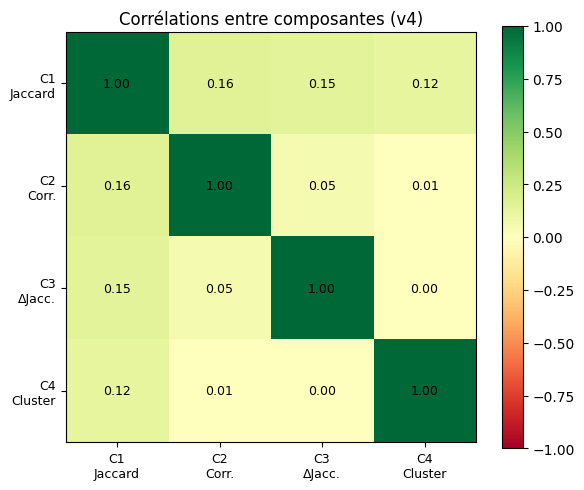


→ En v3 : C1×C3 = -0.41 (anti-corrélation structurelle)
→ En v4 : C1×C3 doit être proche de 0 ou positif
  (ΔJaccard et Jaccard niveau ne mesurent pas la même chose)


In [10]:
# ── Matrice de corrélation ────────────────────────────────────────
# On vérifie que C3_delta (ΔJaccard) n'est plus anti-corrélé à C1
corr_matrix = panel[norm_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
labels = ["C1\nJaccard", "C2\nCorr.", "C3\nΔJacc.", "C4\nCluster"]
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(labels, fontsize=9)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                ha="center", va="center", fontsize=9)
ax.set_title("Corrélations entre composantes (v4)")
plt.tight_layout()
plt.savefig("correlation_v4.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ En v3 : C1×C3 = -0.41 (anti-corrélation structurelle)")
print("→ En v4 : C1×C3 doit être proche de 0 ou positif")
print("  (ΔJaccard et Jaccard niveau ne mesurent pas la même chose)")

---
## Agrégation v4

In [11]:
# ── Indice principal ──────────────────────────────────────────────
panel["CI_v4"] = sum(W[col] * panel[col] for col in norm_cols)
panel["CI_v4"] = (
    (panel["CI_v4"] - panel["CI_v4"].min()) /
    (panel["CI_v4"].max() - panel["CI_v4"].min())
)

# ── Variantes de robustesse ───────────────────────────────────────
# Baseline : C1 seul
panel["CI_C1_only"] = panel["C1_jaccard"]

# C1 + C3 uniquement (les deux composantes Jaccard)
ci_c1c3 = 0.60 * panel["C1_jaccard"] + 0.40 * panel["C3_delta"]
panel["CI_C1_C3"] = (ci_c1c3 - ci_c1c3.min()) / (ci_c1c3.max() - ci_c1c3.min())

# Poids égaux
ci_eq = panel[norm_cols].mean(axis=1)
panel["CI_equal"] = (ci_eq - ci_eq.min()) / (ci_eq.max() - ci_eq.min())

# Sans C2 (mesure apport de la corrélation)
w_nc2 = {"C1_jaccard": 0.50, "C3_delta": 0.35, "C4_cluster": 0.15}
ci_nc2 = sum(w * panel[c] for c, w in w_nc2.items())
panel["CI_no_c2"] = (ci_nc2 - ci_nc2.min()) / (ci_nc2.max() - ci_nc2.min())

print(f"CI_v4 : mean={panel['CI_v4'].mean():.4f}, std={panel['CI_v4'].std():.4f}")
print("\nCorrélations entre variantes :")
display(panel[["CI_v4", "CI_C1_only", "CI_C1_C3", "CI_equal", "CI_no_c2"]].corr().round(3))
print("\n→ En v2 : CI/CI_equal = 0.988 (indiscernables)")
print("→ En v3 : CI/CI_equal = 0.898")
print("→ En v4 : on attend CI/CI_equal < 0.90 et CI/CI_C1_only > 0.80")

CI_v4 : mean=0.4103, std=0.1819

Corrélations entre variantes :


,CI_v4,CI_C1_only,CI_C1_C3,CI_equal,CI_no_c2
CI_v4,1.000,0.813,0.949,0.951,0.968
CI_C1_only,0.813,1.000,0.864,0.664,0.848
CI_C1_C3,0.949,0.864,1.000,0.807,0.985
CI_equal,0.951,0.664,0.807,1.000,0.856
CI_no_c2,0.968,0.848,0.985,0.856,1.000



→ En v2 : CI/CI_equal = 0.988 (indiscernables)
→ En v3 : CI/CI_equal = 0.898
→ En v4 : on attend CI/CI_equal < 0.90 et CI/CI_C1_only > 0.80


---
## Validation sur les cas connus (ground truth)

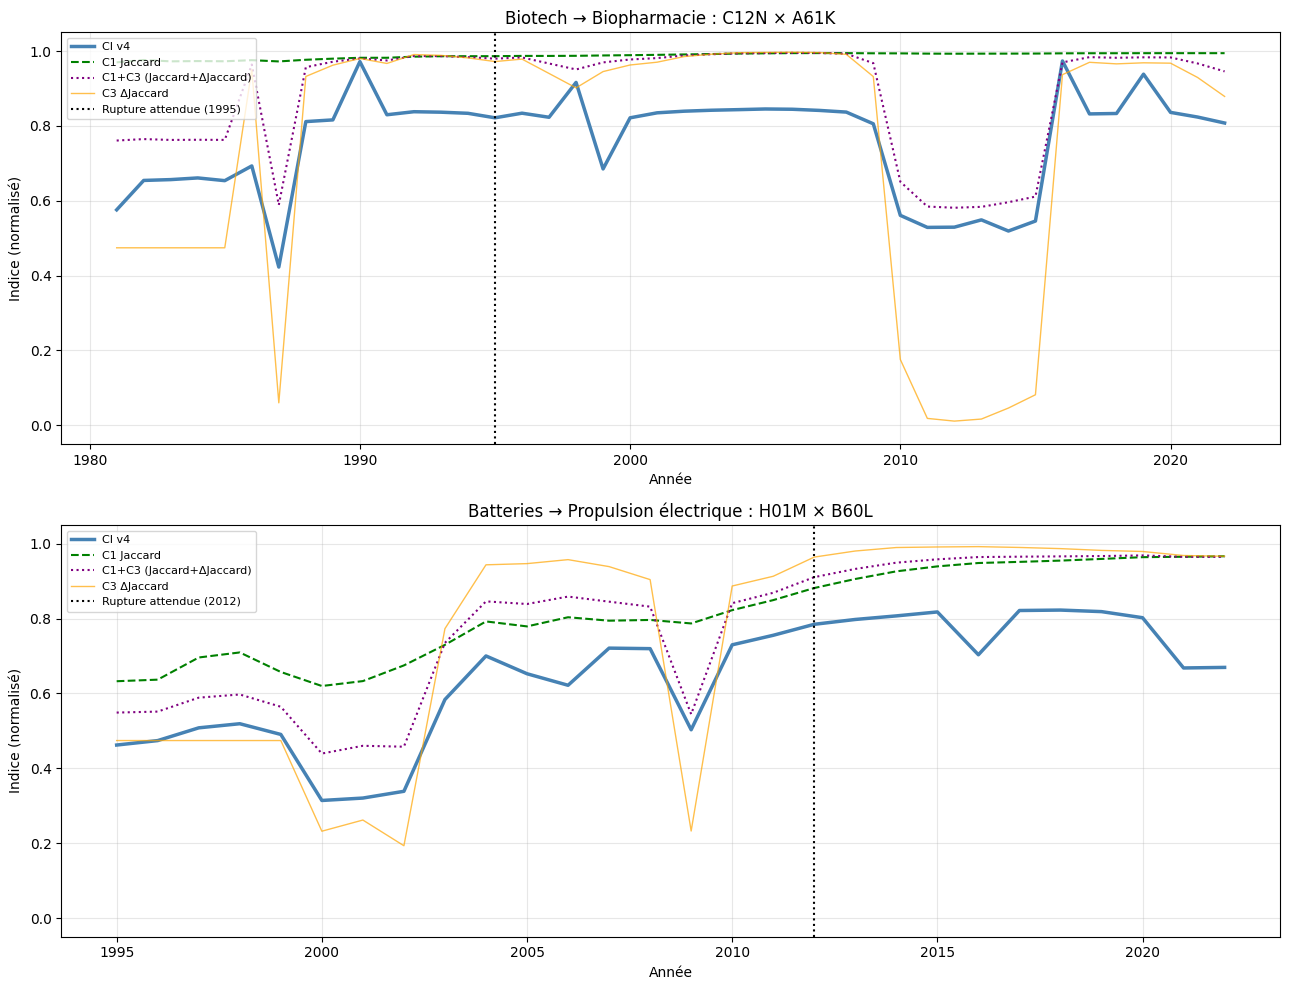

In [12]:
def plot_pair_validation(panel, ci, cj, label, expected_break, ax=None):
    mask = (
        ((panel["cpc_i"] == ci) & (panel["cpc_j"] == cj)) |
        ((panel["cpc_i"] == cj) & (panel["cpc_j"] == ci))
    )
    sub = panel[mask].sort_values("year")
    if len(sub) == 0:
        print(f"⚠ Paire {ci}×{cj} absente du panel")
        return
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 4))
    ax.plot(sub["year"], sub["CI_v4"],    lw=2.5, color="steelblue",  label="CI v4")
    ax.plot(sub["year"], sub["CI_C1_only"],lw=1.5, color="green",  ls="--", label="C1 Jaccard")
    ax.plot(sub["year"], sub["CI_C1_C3"], lw=1.5, color="purple", ls=":",  label="C1+C3 (Jaccard+ΔJaccard)")
    ax.plot(sub["year"], sub["C3_delta"], lw=1.0, color="orange", alpha=0.7, label="C3 ΔJaccard")
    ax.axvline(expected_break, color="black", ls=":", lw=1.5,
               label=f"Rupture attendue ({expected_break})")
    ax.set_title(f"{label} : {ci} × {cj}")
    ax.set_xlabel("Année")
    ax.set_ylabel("Indice (normalisé)")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    return ax


fig, axes = plt.subplots(2, 1, figsize=(13, 10))
plot_pair_validation(panel, "C12N", "A61K",
                     "Biotech → Biopharmacie", expected_break=1995, ax=axes[0])
plot_pair_validation(panel, "H01M", "B60L",
                     "Batteries → Propulsion électrique", expected_break=2012, ax=axes[1])
plt.tight_layout()
plt.savefig("validation_v4.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Top convergences par année

In [13]:
def top_convergences(panel, year, n=10):
    top = (
        panel[panel["year"] == year]
        .nlargest(n, "CI_v4")[
            ["cpc_i", "cpc_j", "CI_v4",
             "C1_jaccard", "C2_corr", "C3_delta", "C4_cluster",
             "jaccard", "delta_jaccard", "n_cooc", "c2_reliability"]
        ]
        .reset_index(drop=True)
    )
    # vérification automatique filtre taxonomique
    if (top["cpc_i"].str[:3] == top["cpc_j"].str[:3]).any():
        print("⚠ Paires taxonomiques présentes !")
    return top


for yr in [1990, 2000, 2010, 2020]:
    print(f"\n── Top 10 en {yr} ──────────────────────────────")
    display(top_convergences(panel, yr, n=10))


── Top 10 en 1990 ──────────────────────────────


,cpc_i,cpc_j,CI_v4,C1_jaccard,C2_corr,C3_delta,C4_cluster,jaccard,delta_jaccard,n_cooc,c2_reliability
0,G06Q,G07F,0.992595,0.999643,0.955068,0.999739,0.941932,0.481928,0.123719,160,0.800
1,F02D,Y02T,0.992018,0.993260,0.971291,0.998334,0.941932,0.187218,0.066999,249,1.000
2,F02B,Y02T,0.989303,0.997730,0.987754,0.975645,0.941932,0.295063,0.018162,514,1.000
3,C07K,C12N,0.988798,0.996770,0.987528,0.999904,0.893035,0.263967,0.151169,515,1.000
4,B01J,C10G,0.986789,0.986060,0.988899,0.982762,0.941932,0.131986,0.022479,333,1.000
5,G06T,H04N,0.977918,0.980458,0.929609,0.992115,0.941932,0.112774,0.034203,113,0.565
6,G06F,H04L,0.977354,0.981062,0.922238,0.993232,0.941932,0.114433,0.036984,111,0.555
7,A61K,C12N,0.971756,0.981981,0.959984,0.980061,0.893035,0.116883,0.020568,369,1.000
8,A61P,C07K,0.965772,0.978724,0.913743,0.988796,0.893035,0.108844,0.028410,448,1.000
9,H02M,Y02B,0.960390,0.975748,0.828247,0.994220,0.941932,0.102439,0.039518,63,0.315



── Top 10 en 2000 ──────────────────────────────


,cpc_i,cpc_j,CI_v4,C1_jaccard,C2_corr,C3_delta,C4_cluster,jaccard,delta_jaccard,n_cooc,c2_reliability
0,G06Q,G07F,0.931652,0.999609,0.928889,0.994522,0.597181,0.476518,0.040212,416,1.000
1,G06F,H04L,0.928589,0.978655,0.979348,0.987644,0.597181,0.108661,0.027047,340,1.000
2,G06T,H04N,0.920494,0.987233,0.955905,0.962597,0.597181,0.137865,0.013591,430,1.000
3,G06Q,H04L,0.907783,0.953080,0.926949,0.982831,0.597181,0.072549,0.022549,111,0.555
4,G06F,H04N,0.907574,0.926812,0.986376,0.987487,0.597181,0.056243,0.026897,282,1.000
5,H01Q,H04B,0.905664,0.973410,0.836612,0.994261,0.597181,0.097854,0.039591,114,0.570
6,G11C,H03K,0.905430,0.966114,0.899488,0.971819,0.597181,0.085376,0.016541,101,0.505
7,D01F,D04H,0.899290,0.982440,0.852513,0.998574,0.508681,0.118301,0.070682,117,0.585
8,C01P,C09C,0.895357,0.999520,0.994782,0.998258,0.296875,0.458388,0.065853,347,1.000
9,C08L,C09J,0.895228,0.990421,0.970557,0.916198,0.508681,0.156510,0.006848,452,1.000



── Top 10 en 2010 ──────────────────────────────


,cpc_i,cpc_j,CI_v4,C1_jaccard,C2_corr,C3_delta,C4_cluster,jaccard,delta_jaccard,n_cooc,c2_reliability
0,H05B,H10K,0.960037,0.991162,0.971517,0.998622,0.746548,0.163511,0.071325,475,1.000
1,C01P,C09C,0.955803,0.999781,0.972704,0.973286,0.746548,0.507260,0.017133,524,1.000
2,C09K,H10K,0.952106,0.987912,0.930103,0.998841,0.746548,0.140893,0.076653,410,1.000
3,C09K,H05B,0.949635,0.961729,0.988337,0.996901,0.746548,0.080332,0.051039,319,1.000
4,C08L,C09D,0.942964,0.989976,0.909560,0.977750,0.746548,0.153298,0.019237,1011,1.000
5,B82Y,C01P,0.938351,0.968583,0.981864,0.955685,0.746548,0.089068,0.012022,299,1.000
6,H01L,H10D,0.937721,0.989921,0.891726,0.970331,0.746548,0.152961,0.015963,744,1.000
7,C08J,C09D,0.934472,0.954040,0.940347,0.983695,0.746548,0.073308,0.023268,379,1.000
8,B82Y,G03F,0.933054,0.936425,0.962741,0.991546,0.746548,0.061084,0.033086,240,1.000
9,A61H,A63B,0.932053,0.981364,0.838738,0.990497,0.746548,0.115192,0.031057,69,0.345



── Top 10 en 2020 ──────────────────────────────


,cpc_i,cpc_j,CI_v4,C1_jaccard,C2_corr,C3_delta,C4_cluster,jaccard,delta_jaccard,n_cooc,c2_reliability
0,F02C,F05D,0.848682,0.998910,0.999328,0.999163,0.0,0.379384,0.086210,4424,1.0
1,C21D,C22C,0.848646,0.998930,0.998649,0.999362,0.0,0.382122,0.093338,2381,1.0
2,F01D,F05D,0.848545,0.999959,0.999321,0.997340,0.0,0.638560,0.054823,7505,1.0
3,F01D,F02C,0.847788,0.997353,0.999897,0.998156,0.0,0.281979,0.064420,3117,1.0
4,G06F,H04L,0.847113,0.997888,0.999774,0.995392,0.0,0.301839,0.043330,12341,1.0
5,B22F,B33Y,0.846666,0.996483,0.991601,0.999952,0.0,0.254267,0.166311,1475,1.0
6,B60Q,F21S,0.846165,0.995872,0.991436,0.999280,0.0,0.237552,0.089475,854,1.0
7,F04D,F05D,0.846052,0.994213,0.999973,0.996873,0.0,0.199937,0.050880,2530,1.0
8,A61P,C07K,0.844632,0.997292,0.995859,0.990380,0.0,0.279216,0.030803,6991,1.0
9,G06T,H04N,0.844135,0.994604,0.991621,0.994528,0.0,0.208069,0.040250,4002,1.0


---
## Évolution temporelle

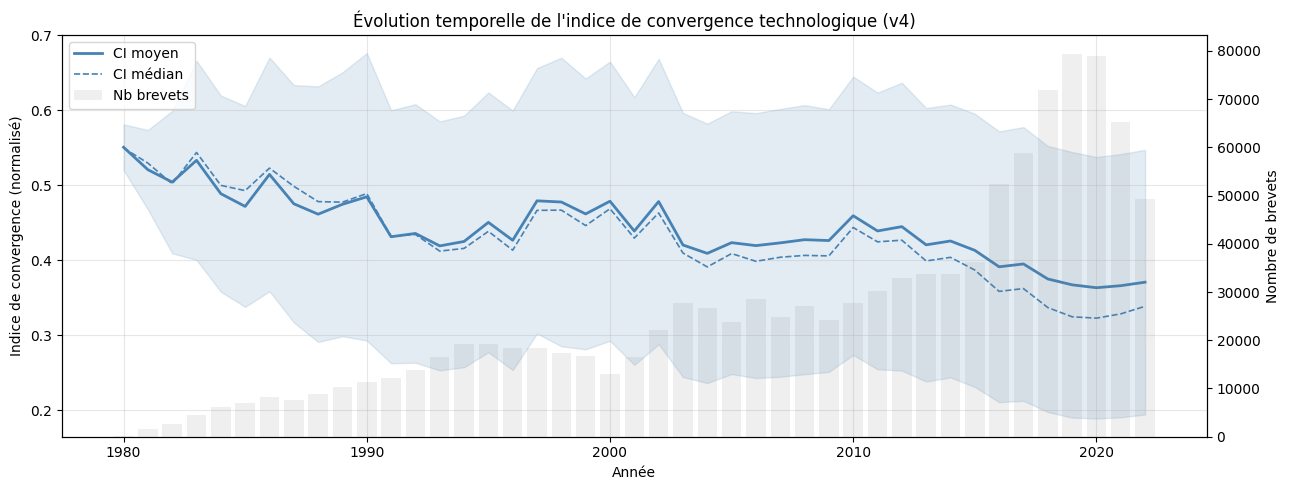


→ On attend une tendance croissante (espace technologique plus interconnecté)
  avec ruptures autour de 1990-1995 (biotech) et 2010-2015 (IA/VE)


In [14]:
yearly_patents = pd.Series(brevet_count_by_year).rename("n_patents")
CI_time = (
    panel.groupby("year")["CI_v4"]
    .agg(["mean", "median", "std"])
    .join(yearly_patents)
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
ax1.fill_between(CI_time.index,
    (CI_time["mean"] - CI_time["std"]).clip(0),
    (CI_time["mean"] + CI_time["std"]).clip(upper=1),
    alpha=0.15, color="steelblue")
ax1.plot(CI_time.index, CI_time["mean"],   color="steelblue", lw=2,   label="CI moyen")
ax1.plot(CI_time.index, CI_time["median"], color="steelblue", lw=1.2, ls="--", label="CI médian")
ax2.bar(CI_time.index, CI_time["n_patents"], alpha=0.12, color="gray", label="Nb brevets")
ax1.set_xlabel("Année")
ax1.set_ylabel("Indice de convergence (normalisé)")
ax2.set_ylabel("Nombre de brevets")
ax1.set_title("Évolution temporelle de l'indice de convergence technologique (v4)")
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, l1 + l2, loc="upper left")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("CI_temporal_v4.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ On attend une tendance croissante (espace technologique plus interconnecté)")
print("  avec ruptures autour de 1990-1995 (biotech) et 2010-2015 (IA/VE)")

---
## Export

In [ ]:
cols_export = [
    "cpc_i", "cpc_j", "year",
    "C1_jaccard", "C2_corr", "C3_delta", "C4_cluster",
    "CI_v4", "CI_C1_only", "CI_C1_C3", "CI_equal", "CI_no_c2",
    "jaccard", "delta_jaccard", "jaccard_lag",
    "p_j_given_i", "p_i_given_j",
    "rolling_corr", "rolling_corr_raw", "c2_reliability", "n_cooc"
]
panel[cols_export].to_parquet("indice_convergence_v4.parquet", index=False)
panel[cols_export].to_csv("indice_convergence_v4.csv", index=False)
print(f"Exporté : {len(panel):,} lignes | {panel['year'].nunique()} années")
panel[cols_export].describe().round(4)